### Controlla se l'immagine è corretta

In [5]:
from PIL import Image

# Replace with your image path
image_path = r"C:\Users\david\Downloads\5827703234473608689.jpg"
image_path = r"C:\Users\david\Downloads\photo_5780414304514851353_w.jpg"
image_path = r"C:\Users\david\Downloads\photo_5780384488851883599_w.jpg"
image_path = r"C:\Users\david\Downloads\photo_5792111811154264806_w.jpg"
image_path = r"C:\Users\david\Downloads\photo_5886609466852491741_w.jpg"
image_path = r"C:\Users\david\Downloads\6010344481058048598.jpg"
image_path = r"C:\Users\david\Downloads\photo_5846220736862210767_w.jpg"
image_path = r"C:\Users\david\Downloads\5803107051989830642.jpg"
image_path = r"C:\Users\david\Downloads\photo_5787638761633025147_w.jpg"
image_path = r"C:\Users\david\Downloads\5911362681938054328.jpg"
#image_path = r"C:\Users\david\Downloads\5911362681938054313.jpg"
# Open the image
image = Image.open(image_path)

# Optional: show it or print its type
print(f"Image size: {image.size}")
print(f"Image mode: {image.mode}")

image.show()

Image size: (834, 960)
Image mode: RGB


### Funzioni



In [6]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import os
from PIL import Image, ImageOps

def debug_show_crop(crop, cols=3):
    plt.figure(figsize=(5, 3))
    plt.imshow(crop)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def crop_to_binary(crop, threshold=69):
    gray = crop.convert("L")
    binary = gray.point(lambda p: 1 if p < threshold else 0, mode='1')
    #binary_pixels = list(binary.getdata())
    return binary

import numpy as np

from PIL import Image
import numpy as np

def find_vertical_black_lines(image):
    img_array = np.array(image)
    height, width = img_array.shape
    vertical_lines = []
    # Check each column - if all pixels are 0 (black), it's a vertical black line
    for x in range(width):
        column = img_array[:, x]
        if np.all(column == 0):  # All pixels are black
            vertical_lines.append(x)
    
    return vertical_lines

def find_horizontal_black_lines(image):
    # Convert to binary array (0 = black, 255 = white)
    img_array = np.array(image)
    height, width = img_array.shape
    
    horizontal_lines = []
    
    # Check from top (y=0) going down
    for y in range(height):
        row = img_array[y, :]
        if np.all(row == 0):  # All pixels are black
            horizontal_lines.append(y)
        else:
            break  # Stop at first non-black row
    
    # Check from bottom (y=height-1) going up
    for y in range(height - 1, -1, -1):
        if y in horizontal_lines:
            break  # Already found this row from top scan
        row = img_array[y, :]
        if np.all(row == 0):  # All pixels are black
            horizontal_lines.append(y)
        else:
            break  # Stop at first non-black row
    
    return sorted(horizontal_lines)

def split_image_by_vertical_lines(image, vertical_lines):
    if not vertical_lines:
        return [image]
    width, height = image.size
    sub_images = []
    vertical_lines = sorted(set(vertical_lines))     # Sort vertical lines and remove duplicates
    line_groups = [] # Group consecutive vertical lines together
    current_group = [vertical_lines[0]]
    for i in range(1, len(vertical_lines)):
        if vertical_lines[i] == vertical_lines[i-1] + 1:
            current_group.append(vertical_lines[i])
        else:
            line_groups.append(current_group)
            current_group = [vertical_lines[i]]
    line_groups.append(current_group)
    split_points = [0]
    for group in line_groups:
        split_points.append(group[-1] + 1)  # After the last line in the group
    split_points.append(width)
    for i in range(len(split_points) - 1):
        left = split_points[i]
        right = split_points[i + 1]
        if right - left > 0:         # Skip if the section is empty or too narrow
            sub_image = image.crop((left, 0, right, height))
            sub_images.append(sub_image)
    return sub_images

def remove_black_lines_from_image(image):
    vertical_lines = find_vertical_black_lines(image)
    horizontal_lines = find_horizontal_black_lines(image)  
    if not vertical_lines and not horizontal_lines:
        return image
    width, height = image.size
    keep_columns = [x for x in range(width) if x not in vertical_lines]
    keep_rows = [y for y in range(height) if y not in horizontal_lines]
    if not keep_columns or not keep_rows:
        return Image.new('1', (1, 1), 1)
    new_width, new_height = len(keep_columns), len(keep_rows)
    new_image = Image.new('1', (new_width, new_height), 1)  # White background
    for new_y, old_y in enumerate(keep_rows):
        for new_x, old_x in enumerate(keep_columns):
            pixel = image.getpixel((old_x, old_y))
            new_image.putpixel((new_x, new_y), pixel)
    return new_image

def process_image_to_remove_black(image):
    vertical_lines = find_vertical_black_lines(image)
    sub_images = split_image_by_vertical_lines(image, vertical_lines)
    cleaned_images = []
    for i, sub_img in enumerate(sub_images):    
        cleaned_img = remove_black_lines_from_image(sub_img)
        if cleaned_img and cleaned_img.size != (1, 1):
            # Padding step
            width, height = cleaned_img.size
            pad_width = max(5 - width, 0)
            pad_height = max(5 - height, 0)

            left = pad_width // 2
            right = pad_width - left
            top = pad_height // 2
            bottom = pad_height - top

            padded_img = ImageOps.expand(cleaned_img, (left, top, right, bottom), fill=0)

            cleaned_images.append(padded_img)

    return cleaned_images

def calculate_ssim(pil1,pil2):
    #Can be made better by loading arrays directly... but later
    pil1 = pil1.convert('L')
    pil2 = pil2.convert('L')

    img1 = np.array(pil1)
    img2 = np.array(pil2)

    if img1.shape != img2.shape:
        pil2 = pil2.resize(pil1.size)
        img2 = np.array(pil2)

    min_dim = min(img1.shape)
    win_size = min(7, min_dim)
    if win_size % 2 == 0:
        win_size -= 1  # must be odd

    score, _ = ssim(img1, img2, full=True, win_size=win_size)
    return score

def compare_with_saved_data_local(splits, folder_path='./output_splits'):
    
    ########################################################
    alphabet = {}
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            key = os.path.splitext(filename)[0]
            image_path = os.path.join(folder_path, filename)
            img = Image.open(image_path)

            # Determine size of padding
            width, height = img.size
            pad_width = max(5 - width, 0)
            pad_height = max(5 - height, 0)

            # Calculate padding for each side to center the image
            left = pad_width // 2
            right = pad_width - left
            top = pad_height // 2
            bottom = pad_height - top

            # Pad only if needed
            padded_img = ImageOps.expand(img, (left, top, right, bottom), fill=0)

            alphabet[key] = padded_img
    # Quando abbiamo tutte le lettere, salviamo il json direttamente
    
    pokemon_probable_name = []
    for sp in splits:
        alph_likeness = [calculate_ssim(sp, alphabet[k]) for k in alphabet.keys()]
        best_match_idx = np.argmax(alph_likeness)
        best_match_key = list(alphabet.keys())[best_match_idx]
        best_match_key = best_match_key.split('_')[0]
        pokemon_probable_name.append(best_match_key)

    try:
        return ''.join(pokemon_probable_name)
    except:
        return ''.join(str(x) for x in pokemon_probable_name)

### Salva tutti i crop in una cartella temp

Decidueye


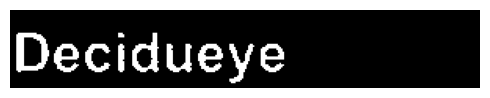

Saved: temp\00split_1.png
Saved: temp\00split_2.png
Saved: temp\00split_3.png
Saved: temp\00split_4.png
Saved: temp\00split_5.png
Saved: temp\00split_6.png
Saved: temp\00split_7.png
Saved: temp\00split_8.png
Saved: temp\00split_9.png
81


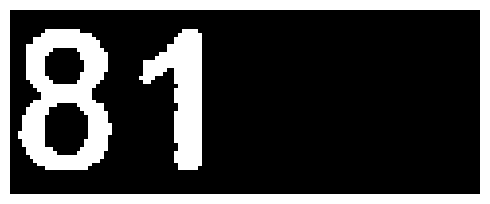

Saved: temp\number_00split_1.png
Saved: temp\number_00split_2.png
429


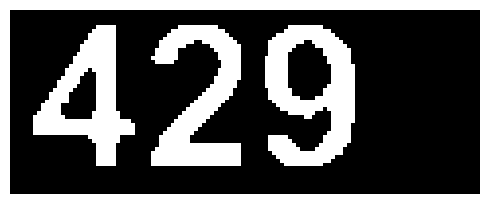

Saved: temp\number_00split_1.png
Saved: temp\number_00split_2.png
Saved: temp\number_00split_3.png
MegaAerodactyl


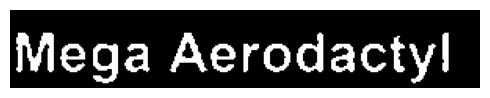

Saved: temp\01split_1.png
Saved: temp\01split_2.png
Saved: temp\01split_3.png
Saved: temp\01split_4.png
Saved: temp\01split_5.png
Saved: temp\01split_6.png
Saved: temp\01split_7.png
Saved: temp\01split_8.png
Saved: temp\01split_9.png
Saved: temp\01split_10.png
Saved: temp\01split_11.png
Saved: temp\01split_12.png
Saved: temp\01split_13.png
Saved: temp\01split_14.png
80


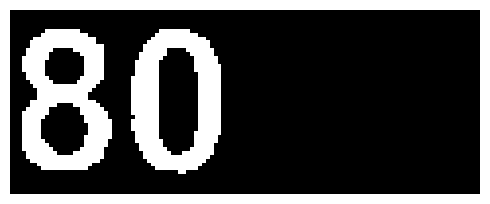

Saved: temp\number_01split_1.png
Saved: temp\number_01split_2.png
452


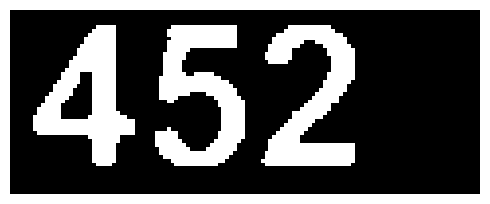

Saved: temp\number_01split_1.png
Saved: temp\number_01split_2.png
Saved: temp\number_01split_3.png
MegaHoundoom


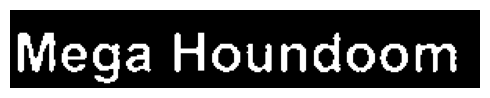

Saved: temp\02split_1.png
Saved: temp\02split_2.png
Saved: temp\02split_3.png
Saved: temp\02split_4.png
Saved: temp\02split_5.png
Saved: temp\02split_6.png
Saved: temp\02split_7.png
Saved: temp\02split_8.png
Saved: temp\02split_9.png
Saved: temp\02split_10.png
Saved: temp\02split_11.png
Saved: temp\02split_12.png
73


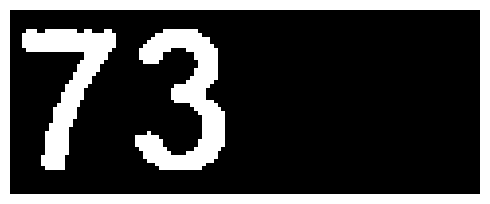

Saved: temp\number_02split_1.png
Saved: temp\number_02split_2.png
402


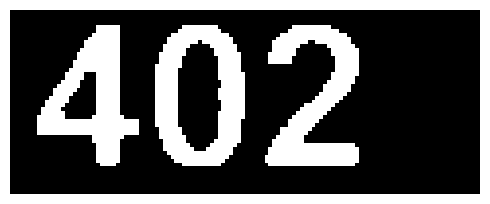

Saved: temp\number_02split_1.png
Saved: temp\number_02split_2.png
Saved: temp\number_02split_3.png
Krookodile


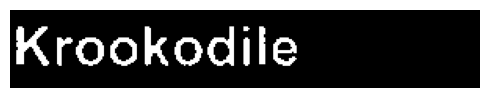

Saved: temp\10split_1.png
Saved: temp\10split_2.png
Saved: temp\10split_3.png
Saved: temp\10split_4.png
Saved: temp\10split_5.png
Saved: temp\10split_6.png
Saved: temp\10split_7.png
Saved: temp\10split_8.png
Saved: temp\10split_9.png
Saved: temp\10split_10.png
77


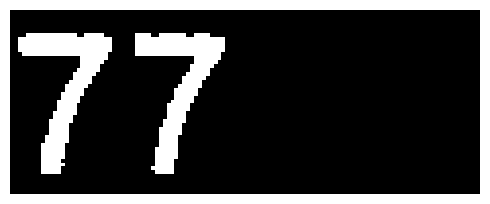

Saved: temp\number_10split_1.png
Saved: temp\number_10split_2.png
40


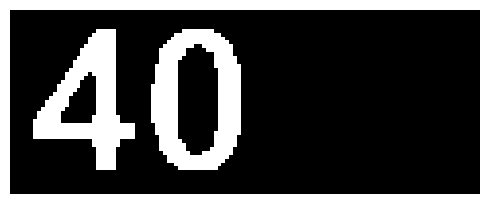

Saved: temp\number_10split_1.png
Saved: temp\number_10split_2.png
Regieleki


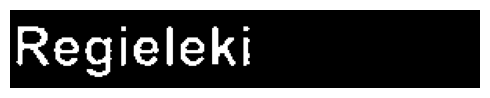

Saved: temp\11split_1.png
Saved: temp\11split_2.png
Saved: temp\11split_3.png
Saved: temp\11split_4.png
Saved: temp\11split_5.png
Saved: temp\11split_6.png
Saved: temp\11split_7.png
Saved: temp\11split_8.png
Saved: temp\11split_9.png
55


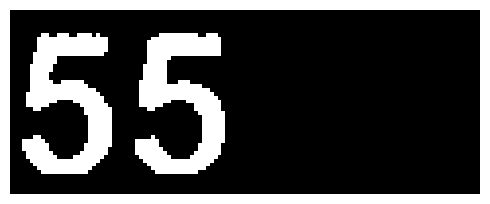

Saved: temp\number_11split_1.png
Saved: temp\number_11split_2.png
308


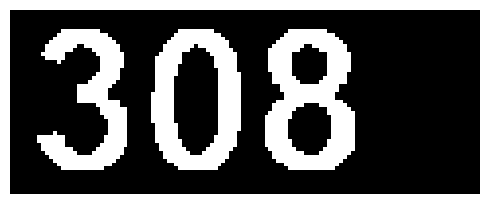

Saved: temp\number_11split_1.png
Saved: temp\number_11split_2.png
Saved: temp\number_11split_3.png
Pelipper


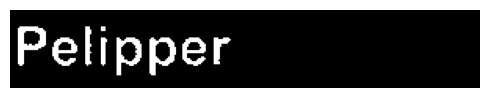

Saved: temp\12split_1.png
Saved: temp\12split_2.png
Saved: temp\12split_3.png
Saved: temp\12split_4.png
Saved: temp\12split_5.png
Saved: temp\12split_6.png
Saved: temp\12split_7.png
Saved: temp\12split_8.png
64


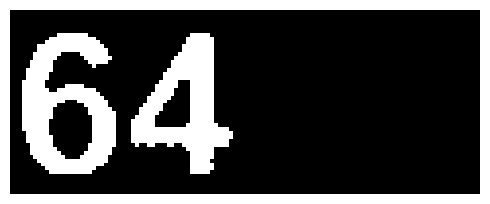

Saved: temp\number_12split_1.png
Saved: temp\number_12split_2.png
282


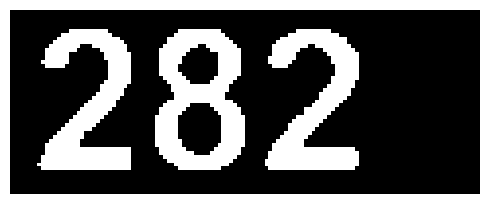

Saved: temp\number_12split_1.png
Saved: temp\number_12split_2.png
Saved: temp\number_12split_3.png
xatu


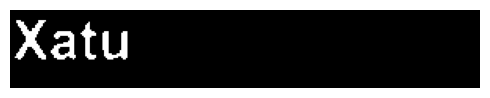

Saved: temp\20split_1.png
Saved: temp\20split_2.png
Saved: temp\20split_3.png
Saved: temp\20split_4.png
50


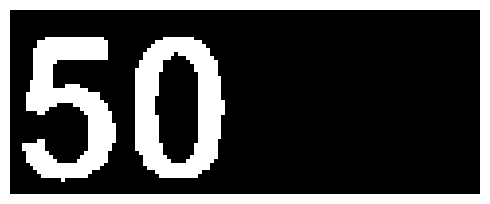

Saved: temp\number_20split_1.png
Saved: temp\number_20split_2.png
235


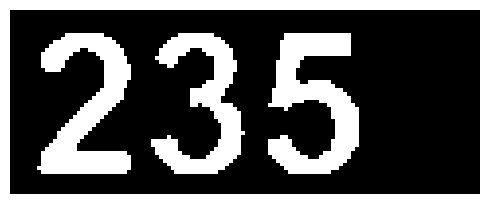

Saved: temp\number_20split_1.png
Saved: temp\number_20split_2.png
Saved: temp\number_20split_3.png
KOmala


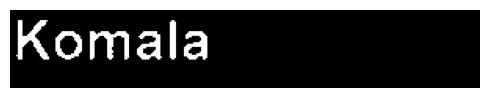

Saved: temp\21split_1.png
Saved: temp\21split_2.png
Saved: temp\21split_3.png
Saved: temp\21split_4.png
Saved: temp\21split_5.png
Saved: temp\21split_6.png
21


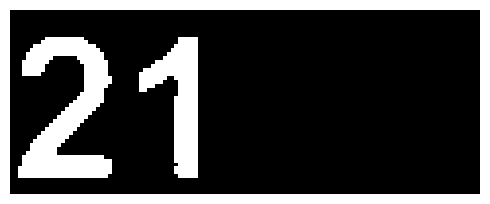

Saved: temp\number_21split_1.png
Saved: temp\number_21split_2.png
101


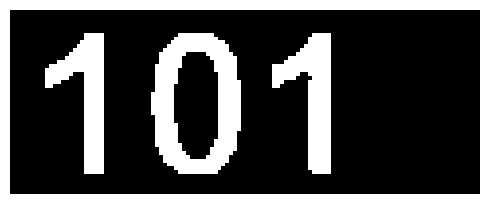

Saved: temp\number_21split_1.png
Saved: temp\number_21split_2.png
Saved: temp\number_21split_3.png
GlOom


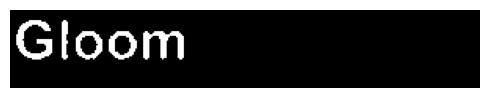

Saved: temp\22split_1.png
Saved: temp\22split_2.png
Saved: temp\22split_3.png
Saved: temp\22split_4.png
Saved: temp\22split_5.png
36


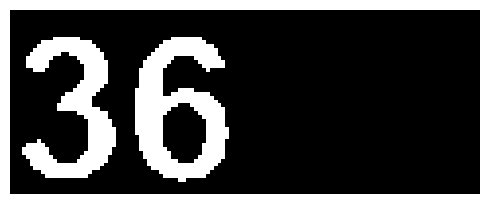

Saved: temp\number_22split_1.png
Saved: temp\number_22split_2.png
142


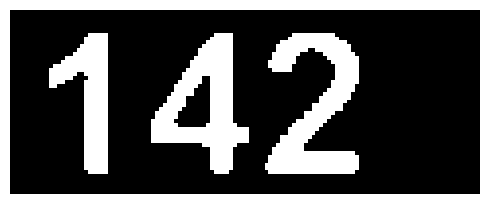

Saved: temp\number_22split_1.png
Saved: temp\number_22split_2.png
Saved: temp\number_22split_3.png
Result: <PIL.Image.Image image mode=RGB size=120x47 at 0x162C1660C20>


In [7]:
async def automatic_card_reader(image):
    width, height = image.size
    if (width, height) != (1667, 1920):
        image = image.resize((1667, 1920), Image.LANCZOS)
    # Estrai i nomi e i livelli:
    name_boxes = []

    for row in range(3):
        for col in range(3):
            box_width = 300
            box_height = 50    
            left = 596 + col * 345
            upper = 50 + row * 618
            right = left + box_width
            lower = upper + box_height
            name_crop = image.crop((left, upper, right, lower))
            binary_img = crop_to_binary(name_crop)
            
            splits = process_image_to_remove_black(binary_img)
            pokemon_probable_name = compare_with_saved_data_local(splits, folder_path='./')
            print(pokemon_probable_name)

            ### DEBUG #######################################################################################################
            debug_show_crop(binary_img)
            
            import os
            def save_binary_images(images, output_dir="temp", prefix="split"):
                os.makedirs(output_dir, exist_ok=True)
            
                for i, img in enumerate(images):
                    path = os.path.join(output_dir, f"{row}{col}{prefix}_{i+1}.png")
                    img.save(path)
                    print(f"Saved: {path}")
            save_binary_images(splits)

            #################################################################################################################   
            
            box_width = 120
            box_height = 47
            left = 740 + col * 345
            upper = 561 + row * 613
            right = left + box_width
            lower = upper + box_height
            name_crop = image.crop((left, upper, right, lower))
            binary_img = crop_to_binary(name_crop)
            
            splits = process_image_to_remove_black(binary_img)
            pokemon_probable_name = compare_with_saved_data_local(splits, folder_path='./')
            print(pokemon_probable_name)
            
            ### DEBUG #######################################################################################################
            debug_show_crop(binary_img)
            
            import os
            def save_binary_images(images, output_dir="temp", prefix="split"):
                os.makedirs(output_dir, exist_ok=True)
            
                for i, img in enumerate(images):
                    path = os.path.join(output_dir, f"number_{row}{col}{prefix}_{i+1}.png")
                    img.save(path)
                    print(f"Saved: {path}")
            save_binary_images(splits)

            ################################################################################################################# 


            box_width = 120
            box_height = 47
            left = 760 + col * 345
            upper = 510 + row * 613
            right = left + box_width
            lower = upper + box_height
            name_crop = image.crop((left, upper, right, lower))
            binary_img = crop_to_binary(name_crop)
            
            splits = process_image_to_remove_black(binary_img)
            pokemon_probable_name = compare_with_saved_data_local(splits, folder_path='./')
            print(pokemon_probable_name)
            
            ### DEBUG #######################################################################################################
            debug_show_crop(binary_img)
            
            import os
            def save_binary_images(images, output_dir="temp", prefix="split"):
                os.makedirs(output_dir, exist_ok=True)
            
                for i, img in enumerate(images):
                    path = os.path.join(output_dir, f"number_{row}{col}{prefix}_{i+1}.png")
                    img.save(path)
                    print(f"Saved: {path}")
            save_binary_images(splits)

            ################################################################################################################# 
    return name_crop

dic = await automatic_card_reader(image)
print(f"Result: {dic}")

### Trasforma la cartella in json

In [8]:
########################################################
import base64
from PIL import Image, ImageOps
from io import BytesIO
import json


folder_path = "./"
alphabet = {}
for filename in os.listdir(folder_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        key = os.path.splitext(filename)[0]
        image_path = os.path.join(folder_path, filename)
        img = Image.open(image_path)

        # Determine size of padding
        width, height = img.size
        pad_width = max(5 - width, 0)
        pad_height = max(5 - height, 0)

        # Calculate padding for each side to center the image
        left = pad_width // 2
        right = pad_width - left
        top = pad_height // 2
        bottom = pad_height - top

        # Pad only if needed
        padded_img = ImageOps.expand(img, (left, top, right, bottom), fill=0)

        # Convert image to base64
        buffered = BytesIO()
        padded_img.save(buffered, format="PNG")
        img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")

        alphabet[key] = img_str


# Quando abbiamo tutte le lettere, salviamo il json direttamente

# Save dictionary to JSON
with open("alphabet.json", "w") as f:
    json.dump(alphabet, f)